In [3]:
from matplotlib import pyplot as plt

import numpy as np

import pandas as pd

In [28]:
def gen_auroc_cols(num_classes, prefix):
    return list(
        map(
            lambda i: f"{prefix}_auroc_c{i}",
            range(num_classes)
        )
    )
gen_auroc_cols(6, "orig")

['orig_auroc_c0',
 'orig_auroc_c1',
 'orig_auroc_c2',
 'orig_auroc_c3',
 'orig_auroc_c4',
 'orig_auroc_c5']

In [30]:
def load_data(
    model_name,
    layer,
    dataset_name,
    basis_name,
):
    df = pd.read_csv(f"../../artifacts/2024-11-s42-2024-11-s42--selected-classes-and-others/experiments/aurocs/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.csv")

    num_classes = len(list(
        filter(lambda c: "orig_auroc_c" in c, df.columns)
    ))



    for prefix in ["orig", "train", "val"]:
        cols = gen_auroc_cols(num_classes, prefix)
        df[f"{prefix}_auroc_mean"] = df[cols].mean(axis=1)
        df[f"{prefix}_auroc_median"] = df[cols].median(axis=1)
        df[f"{prefix}_auroc_min"] = df[cols].min(axis=1)
    
    return df
    
_df = load_data(
    model_name="imagenet-resnet18-tv",
    layer="layer1",
    dataset_name="imagenet-butterfly-and-5-others",
    basis_name="pca"
)
_df 

,k,orig_loss,orig_accuracy,orig_auroc_c0,orig_auroc_c1,orig_auroc_c2,orig_auroc_c3,orig_auroc_c4,orig_auroc_c5,orig_auroc_c6,...,val_auroc_c6,orig_auroc_mean,orig_auroc_median,orig_auroc_min,train_auroc_mean,train_auroc_median,train_auroc_min,val_auroc_mean,val_auroc_median,val_auroc_min
0,1,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.577267,0.997274,0.99772,0.99296,0.616420,0.567545,0.507229,0.601569,0.57436,0.50536
1,8,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.966467,0.997274,0.99772,0.99296,0.897573,0.891844,0.834494,0.878581,0.87044,0.81148
2,15,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.996493,0.997274,0.99772,0.99296,0.990695,0.989574,0.983452,0.983025,0.98136,0.97388
3,22,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999267,0.997274,0.99772,0.99296,0.996097,0.995267,0.992688,0.992672,0.99284,0.98508
4,29,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999840,0.997274,0.99772,0.99296,0.997899,0.997186,0.995969,0.996731,0.99732,0.99356
5,36,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999907,0.997274,0.99772,0.99296,0.998408,0.997827,0.996884,0.997370,0.99796,0.99312
6,43,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999920,0.997274,0.99772,0.99296,0.998626,0.997997,0.997449,0.997177,0.99776,0.99240
7,50,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999933,0.997274,0.99772,0.99296,0.998661,0.998045,0.997552,0.997128,0.99768,0.99284
8,57,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999933,0.997274,0.99772,0.99296,0.998707,0.998117,0.997630,0.997316,0.99776,0.99304
9,64,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999920,0.997274,0.99772,0.99296,0.998696,0.998139,0.997526,0.997269,0.99772,0.99292


7

In [7]:
load_data(
    model_name="imagenet-resnet18-tv",
    layer="layer1",
    dataset_name="imagenet-butterfly-and-5-others",
    basis_name="prca-sortabs"
)

,k,orig_loss,orig_accuracy,orig_auroc_c0,orig_auroc_c1,orig_auroc_c2,orig_auroc_c3,orig_auroc_c4,orig_auroc_c5,orig_auroc_c6,...,train_auroc_c6,val_loss,val_acc,val_auroc_c0,val_auroc_c1,val_auroc_c2,val_auroc_c3,val_auroc_c4,val_auroc_c5,val_auroc_c6
0,1,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.543673,6.298420,0.454545,0.73872,0.53128,0.67240,0.51304,0.51880,0.50952,0.552820
1,8,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.942211,1.304429,0.561818,0.78472,0.90604,0.93196,0.92364,0.88656,0.85164,0.947827
2,15,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999607,0.300064,0.909091,0.98932,0.98632,0.98620,0.99408,0.98676,0.99432,0.999107
3,22,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999929,0.194022,0.941818,0.99616,0.99736,0.99580,0.99732,0.99112,0.99700,0.999813
4,29,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999970,0.160656,0.950909,0.99840,0.99796,0.99748,0.99648,0.99280,0.99748,0.999960
5,36,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999973,0.159435,0.954545,0.99812,0.99756,0.99740,0.99596,0.99284,0.99780,0.999933
6,43,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999966,0.160028,0.960000,0.99872,0.99764,0.99716,0.99596,0.99284,0.99752,0.999933
7,50,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999966,0.159977,0.958182,0.99856,0.99788,0.99768,0.99556,0.99220,0.99744,0.999920
8,57,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999968,0.157344,0.956364,0.99856,0.99796,0.99784,0.99564,0.99264,0.99788,0.999920
9,64,0.155472,0.958182,0.99868,0.99804,0.99732,0.99628,0.99296,0.99772,0.99992,...,0.999967,0.155447,0.958182,0.99868,0.99804,0.99732,0.99628,0.99292,0.99772,0.999920


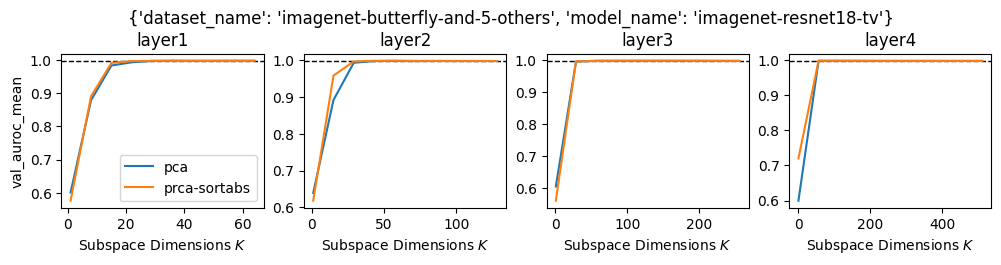

In [39]:
def viz(
    dataset_name,
    model_name="imagenet-resnet18-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"]
):

    arr_attrs = [
        # "val_loss", 
        # "val_acc", 
        "val_auroc_mean",
        # "val_auroc_median",
        # "val_auroc_min",
    ]
    ncols = len(arr_layers)
    nrows = len(arr_attrs)
    plt.figure(figsize=(3*ncols, 2*nrows))
    query = dict(
            dataset_name=dataset_name,
            model_name=model_name,
        )
    plt.suptitle(query, y=1.1)

    for aix, attr_name in enumerate(arr_attrs):        
        for lix, layer in enumerate(arr_layers):
            plt.subplot(nrows, ncols, aix * ncols + 1 + lix)
            if aix == 0:
                plt.title(f"{layer}")
    
            for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
                df = load_data(
                    **query,
                    layer=layer,
                    basis_name=basis_name
                )
                if bix == 0:
                    plt.axhline(df[attr_name].values[-1], ls="--", lw=1, color="k")
    
                plt.plot(
                    df.k,
                    df[attr_name],
                    label=basis_name
                )
            if lix == 0:
                plt.ylabel(attr_name)

            if lix == aix == 0:
                plt.legend()
            if aix == nrows - 1:
                plt.xlabel("Subspace Dimensions $K$")
        
viz(
    dataset_name="imagenet-butterfly-and-5-others"
)

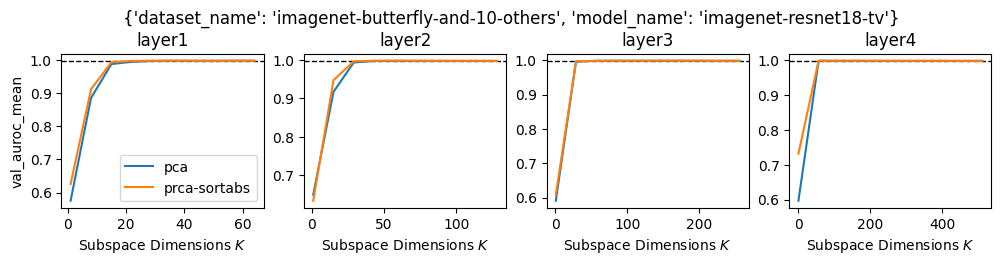

In [41]:
viz(
    dataset_name="imagenet-butterfly-and-10-others"
)

FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2024-11-s42-2024-11-s42--selected-classes-and-others/experiments/aurocs/imagenet-butterfly-and-50-others/imagenet-resnet18-tv/layer1/prca-sortabs--uncentered/accuracy.csv'

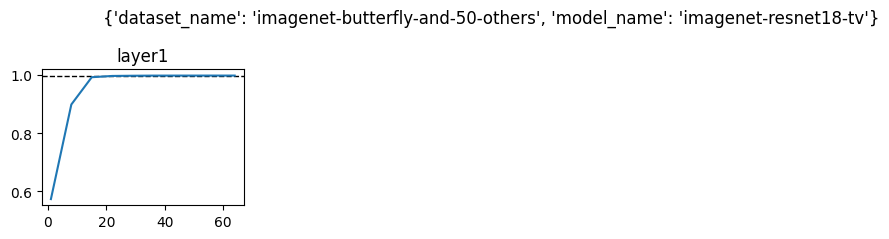

In [35]:
viz(
    dataset_name="imagenet-butterfly-and-50-others"
)